### Loading & Preprocessing Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

file_path = 'data/stroke_prediction_dataset.csv'
df = pd.read_csv(file_path)

In [ ]:
drop_cols = ['Patient ID', 'Patient Name', 'Symptoms']
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

df_model['Diagnosis'] = df_model['Diagnosis'].map({'Stroke': 1, 'No Stroke': 0})

if 'Blood Pressure Levels' in df_model.columns:
    df_model['BP_Systolic'] = df_model['Blood Pressure Levels'].str.extract(r'(\d+)/').astype(float)
    df_model['BP_Diastolic'] = df_model['Blood Pressure Levels'].str.extract(r'/(\d+)').astype(float)
    df_model = df_model.drop(columns=['Blood Pressure Levels'])

if 'Cholesterol Levels' in df_model.columns:
    df_model['HDL'] = df_model['Cholesterol Levels'].str.extract(r'HDL:\s*(\d+)').astype(float)
    df_model['LDL'] = df_model['Cholesterol Levels'].str.extract(r'LDL:\s*(\d+)').astype(float)
    df_model = df_model.drop(columns=['Cholesterol Levels'])

le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

df_model = df_model.fillna(df_model.median(numeric_only=True))

### Training & Evaluation

In [13]:
X = df_model.drop(columns=['Diagnosis'])
y = df_model['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]}")
print(f"Test set:     {X_test.shape[0]}")
print(f"\nClass balance in test set:")
print(y_test.value_counts())

Training set: 12000
Test set:     3000

Class balance in test set:
Diagnosis
0    1506
1    1494
Name: count, dtype: int64


In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear Regression':   LinearRegression(),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
}

needs_scaling = {'Logistic Regression', 'Linear Regression', 'K-Nearest Neighbors'}

results = []
cm_dict = {}

for name, model in models.items():
    if name in needs_scaling:
        model.fit(X_train_scaled, y_train)
        raw_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        raw_pred = model.predict(X_test)

    if name == 'Linear Regression':
        y_pred = (raw_pred >= 0.5).astype(int)
    else:
        y_pred = raw_pred

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)

    results.append({
        'Model':     name,
        'Accuracy':  round(acc,  4),
        'Precision': round(prec, 4),
        'Recall':    round(rec,  4),
        'F1-Score':  round(f1,   4),
    })
    cm_dict[name] = cm

results_df = pd.DataFrame(results).set_index('Model')
print("Model Evaluation Results (Positive class = Stroke)")
print(results_df.to_string())

Model Evaluation Results (Positive class = Stroke)
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.4880     0.4849  0.4518    0.4678
Linear Regression      0.4880     0.4849  0.4518    0.4678
Decision Tree          0.4900     0.4889  0.5308    0.5090
Random Forest          0.4997     0.4975  0.4625    0.4794
K-Nearest Neighbors    0.4957     0.4937  0.4973    0.4955


### Evaluation Model Comparison

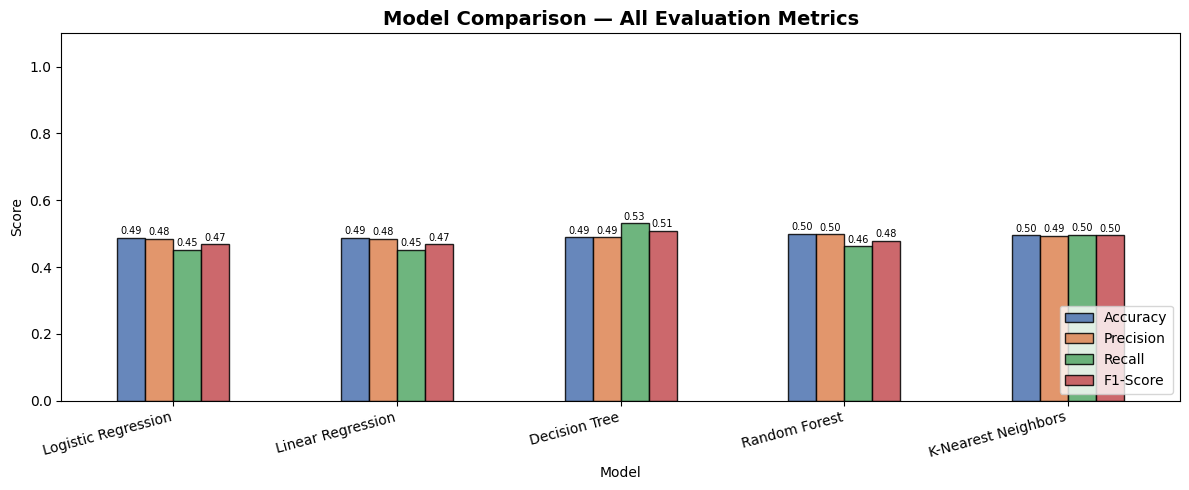

In [11]:
ax = results_df.plot(
    kind='bar', figsize=(12, 5), ylim=(0, 1.1),
    color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'],
    edgecolor='black', alpha=0.85
)
ax.set_title('Model Comparison — All Evaluation Metrics', fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.01),
                ha='center', fontsize=7, color='black')
plt.tight_layout()
plt.show()